# Team 08 - Leekhith: Agent B (PPO view refiner) + integration + team results
Runtime: CPU is fine. Run Step 1 in every new session.

Needs `team08` in YOUR My Drive (Shared with me -> right-click team08 -> Organize -> Add shortcut -> My Drive).

## Step 1 - Mount, unpack, install

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/RL_Project/files_coding/For_Leekhith'
!mkdir -p $DRIVE/results
!rm -rf /content/uav_inspection
!unzip -o -q $DRIVE/uav_inspection.zip -d /content/
%cd /content/uav_inspection
!pip install -q gymnasium stable-baselines3 tensorboard
!ls scripts

Mounted at /content/drive
/content/uav_inspection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.2 MB/s eta 0:00:00
build_detector_cache.py  run_baselines.py  train_agent_a.py
_path.py		 run_full_mode.py  train_agent_b.py
__pycache__		 test_env.py	   train_agent_c.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 - Smoke test + baselines for your mode
Look at the `refine` block: random / fixed_orbit fail, scripted_approach is an upper bound.

In [ ]:
!python scripts/test_env.py | tail -1
!python scripts/run_baselines.py --out $DRIVE/results

ALL TESTS PASSED

=== navigate (analytic) ===
random             return= -29.56±8.62  success=0.00  steps= 148.7  cov=0.51  unc=0.662  found=10.2/26  mIoU=0.244  energy=1.002
raster_mid         return=   6.20±0.07  success=0.00  steps= 199.0  cov=1.00  unc=0.351  found=20.9/26  mIoU=0.500  energy=1.000
raster_low         return=  35.43±0.09  success=1.00  steps= 123.0  cov=0.95  unc=0.219  found=23.5/26  mIoU=0.626  energy=0.625

=== refine (analytic) ===
random             return=  -2.24±0.17  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
fixed_orbit        return=  -2.29±0.08  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
scripted_approach  return=   5.68±0.16  success=1.00  steps=   3.5  cov=0.08  unc=0.961  found=1.2/26  mIoU=0.028  energy=0.028

=== supervise (analytic) ===
random             return=   4.07±9.13  success=1.00  steps=   3.0  cov=0.16  unc=0.903  found=3.0/26  mIoU=0.072  energy=0.06

# PART 1 - Agent B (your viva component)
## Step 3 - Train Agent B with PPO (~2-4 min)

In [ ]:
!python scripts/train_agent_b.py --steps 100000 --out $DRIVE/agentB

2026-09-26 18:01:20.628705: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Logging to /content/drive/MyDrive/RL_Project/files_coding/For_Leekhith/agentB/tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 28.4     |
|    ep_rew_mean     | -1.07    |
| time/              |          |
|    fps             | 1984     |
|    iter

## Step 4 - Learning curves + results table

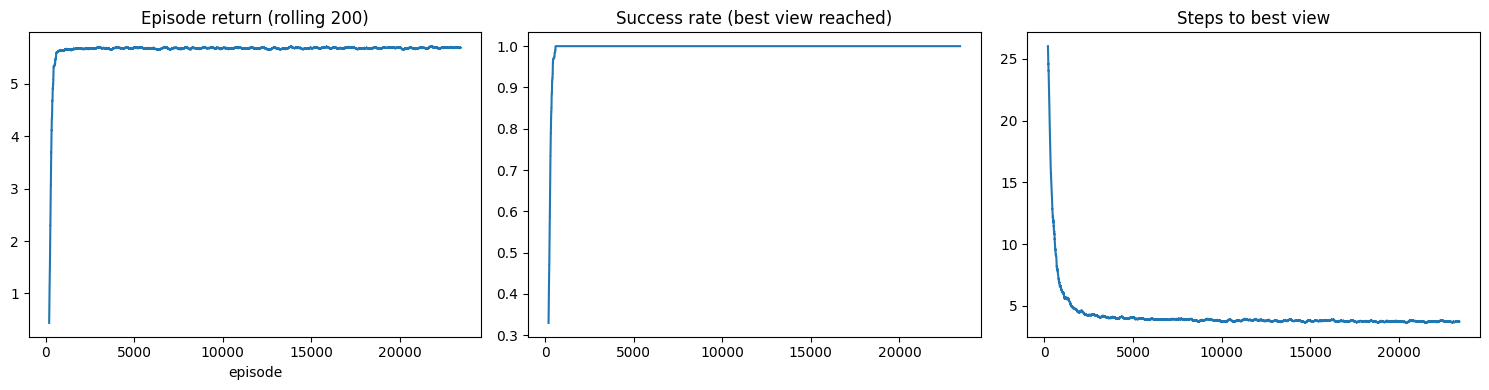

,policy,return_mean,success_mean,steps_mean,energy_used_mean,train_minutes
0,PPO (Agent B),5.670,1.00,3.66,0.029,2.1
1,fixed_orbit,-2.283,0.00,30.00,0.240,2.1
2,random,-2.042,0.02,29.82,0.239,2.1
3,scripted_approach (upper bound),5.674,1.00,3.64,0.029,2.1


In [ ]:
import glob, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
df = pd.concat([pd.read_csv(f, skiprows=1) for f in glob.glob(f'{DRIVE}/agentB/monitor/*.monitor.csv')]).sort_values('t')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['r'].rolling(200).mean().values); ax[0].set_title('Episode return (rolling 200)'); ax[0].set_xlabel('episode')
ax[1].plot(df['success'].astype(float).rolling(200).mean().values); ax[1].set_title('Success rate (best view reached)')
ax[2].plot(df['l'].rolling(200).mean().values); ax[2].set_title('Steps to best view')
plt.tight_layout(); plt.savefig(f'{DRIVE}/agentB/learning_curves.png', dpi=150); plt.show()
pd.read_csv(f'{DRIVE}/agentB/agentB_vs_baselines.csv')[['policy','return_mean','success_mean','steps_mean','energy_used_mean','train_minutes']].round(3)

## Step 5 - Live demo: state -> Gaussian policy -> action -> reward -> next state (CO3)

In [ ]:
import torch
from stable_baselines3 import PPO
from env import InspectionEnv
agent = PPO.load(f'{DRIVE}/agentB/best/best_model.zip', device='cpu')
env = InspectionEnv('refine'); obs, info = env.reset(seed=1000)
NAMES = ['distance', 'angle', 'lateral', 'target_u', 'battery', 'time_left']
for t in range(8):
    print(f'--- t={t} state:', {n: round(float(v), 2) for n, v in zip(NAMES, obs)}, f'view quality s={env.s:.2f}')
    with torch.no_grad():
        dist = agent.policy.get_distribution(agent.policy.obs_to_tensor(obs)[0]).distribution
    mu, sd = dist.mean[0].numpy(), dist.stddev[0].numpy()
    print('   policy N(mu, sigma): mu =', np.round(mu, 2), ' sigma =', np.round(sd, 2))
    obs, r, term, trunc, info = env.step(mu)
    print(f'   ACTION [d_dist, d_angle, d_lateral] = {np.round(np.clip(mu, -1, 1), 2)}  REWARD = {r:+.3f}')
    if term or trunc: print('   -> best view reached (q=4), episode ends'); break

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- t=0 state: {'distance': 0.83, 'angle': -0.28, 'lateral': 0.13, 'target_u': 0.31, 'battery': 1.0, 'time_left': 1.0} view quality s=0.35
   policy N(mu, sigma): mu = [-2.24  1.32 -0.54]  sigma = [0.58 0.56 0.59]
   ACTION [d_dist, d_angle, d_lateral] = [-1.    1.   -0.54]  REWARD = +0.098
--- t=1 state: {'distance': 0.63, 'angle': -0.08, 'lateral': 0.02, 'target_u': 0.31, 'battery': 0.99, 'time_left': 0.97} view quality s=0.58
   policy N(mu, sigma): mu = [-2.26  0.59 -0.02]  sigma = [0.58 0.56 0.59]
   ACTION [d_dist, d_angle, d_lateral] = [-1.    0.59 -0.02]  REWARD = +0.236
--- t=2 state: {'distance': 0.43, 'angle': 0.04, 'lateral': 0.01, 'target_u': 0.13, 'battery': 0.98, 'time_left': 0.93} view quality s=0.72
   policy N(mu, sigma): mu = [-2.1  -0.16 -0.02]  sigma = [0.58 0.56 0.59]
   ACTION [d_dist, d_angle, d_lateral] = [-1.   -0.16 -0.02]  REWARD = +0.052
--- t=3 state: {'distance': 0.23, 'angle': 0.0, 'lateral': 0.01, 'target_u': 0.13, 'battery': 0.98, 'time_left': 0.9} vie

## Step 6 - Convergence + sample efficiency (CO4)

Episodes: 23420, env steps: 100,345
Convergence (success >= 95%): episode 436 = 8,555 env steps


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


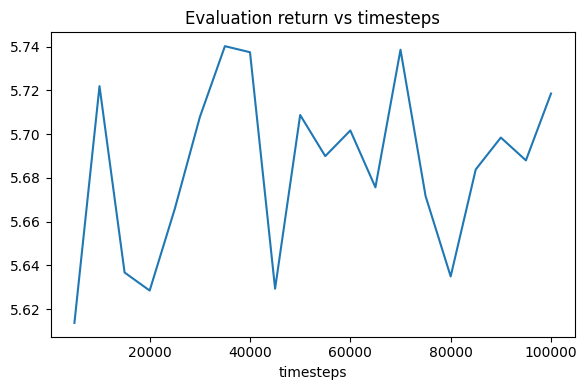

In [ ]:
succ = df['success'].astype(float).rolling(200).mean().values; cum = df['l'].cumsum().values
conv = int(np.argmax(succ >= 0.95)) if (succ >= 0.95).any() else None
print(f'Episodes: {len(df)}, env steps: {int(cum[-1]):,}')
if conv is not None: print(f'Convergence (success >= 95%): episode {conv} = {int(cum[conv]):,} env steps')
ev = np.load(f'{DRIVE}/agentB/eval/evaluations.npz')
plt.figure(figsize=(6, 4)); plt.plot(ev['timesteps'], ev['results'].mean(1)); plt.title('Evaluation return vs timesteps')
plt.xlabel('timesteps'); plt.tight_layout(); plt.savefig(f'{DRIVE}/agentB/eval_curve.png', dpi=150); plt.show()

## Step 7 - Exploration sensitivity: entropy coefficient + clip range (CO5, ~10 min)

In [ ]:
for ent in [0.0, 0.01, 0.05]:
    !python scripts/train_agent_b.py --steps 60000 --ent_coef {ent} --out $DRIVE/agentB_ent{ent}
for clip in [0.1, 0.3]:
    !python scripts/train_agent_b.py --steps 60000 --clip {clip} --out $DRIVE/agentB_clip{clip}

Streaming output truncated to the last 5000 lines.
|    approx_kl            | 0.0071006063 |
|    clip_fraction        | 0.0815       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.93        |
|    explained_variance   | 0.91         |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0494      |
|    n_updates            | 270          |
|    policy_gradient_loss | -0.00931     |
|    std                  | 0.639        |
|    value_loss           | 0.00288      |
------------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.09        |
|    ep_rew_mean          | 5.68        |
| time/                   |             |
|    fps                  | 868         |
|    iterations           | 29          |
|    time_elapsed         | 34          |
|    total_timesteps      | 29696       |
| train/                  |             |
|    approx_k

In [ ]:
rows = []
for tag in ['ent0.0', 'ent0.01', 'ent0.05', 'clip0.1', 'clip0.3']:
    r = pd.read_csv(f'{DRIVE}/agentB_{tag}/agentB_vs_baselines.csv').iloc[0]
    d = pd.concat([pd.read_csv(f, skiprows=1) for f in glob.glob(f'{DRIVE}/agentB_{tag}/monitor/*.monitor.csv')]).sort_values('t')
    s = d['success'].astype(float).rolling(200).mean().values; c = d['l'].cumsum().values
    conv = int(c[np.argmax(s >= 0.95)]) if (s >= 0.95).any() else None
    rows.append({'run': tag, 'return': round(r.return_mean, 2), 'success': r.success_mean, 'steps': r.steps_mean, 'env_steps_to_95%': conv})
pd.DataFrame(rows)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,run,return,success,steps,env_steps_to_95%
0,ent0.0,5.67,1.0,3.66,8555
1,ent0.01,5.67,1.0,3.70,7856
2,ent0.05,5.67,1.0,3.64,8396
3,clip0.1,5.67,1.0,3.66,13139
4,clip0.3,5.67,1.0,3.66,6442


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# PART 2 - Integration (after Yeseswini's Agent A and Mukhesh's Agent C exist in Drive)
## Step 8 - Run all three agents together (team demo + ablation)

In [2]:
!python scripts/run_full_mode.py --a $DRIVE/agentA/best/best_model.zip --b $DRIVE/agentB/best/best_model.zip \
     --c $DRIVE/agentC/best/best_model.zip --out $DRIVE/full

2026-09-27 06:33:45.535398: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Traceback (most recent call last):
  File "/content/uav_inspection/scripts/run_full_mode.py", line 29, in <module>
    A = sb3_policy(DQN.load(args.a, device="cpu"))
                   ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/base_class.py", line 681, in

## Step 9 - Team results summary (for team slides + team poster)

In [3]:
def first_row(path, label):
    r = pd.read_csv(path).iloc[0]; return {'component': label, 'return': round(r.return_mean, 2), 'success': r.success_mean,
                                             'steps': r.steps_mean, 'energy': round(r.energy_used_mean, 3)}
team = [first_row(f'{DRIVE}/agentA/agentA_vs_baselines.csv', 'Agent A - DQN navigation'),
        first_row(f'{DRIVE}/agentB/agentB_vs_baselines.csv', 'Agent B - PPO refinement'),
        first_row(f'{DRIVE}/agentC/agentC_vs_baselines.csv', 'Agent C - A2C supervisor')]
display(pd.DataFrame(team))
full = pd.read_csv(f'{DRIVE}/full/full_mode_results.csv')
display(full[['config','return_mean','success_mean','coverage_mean','defects_found_mean','miou_mean','energy_used_mean']].round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 4)); names = [c.split('(')[0].strip() for c in full['config']]
ax[0].barh(names, full['energy_used_mean']); ax[0].set_title('Energy used per mission (lower = better)')
ax[1].barh(names, full['defects_found_mean']); ax[1].set_title('Defects found (of 26)')
plt.tight_layout(); plt.savefig(f'{DRIVE}/full/team_summary.png', dpi=150); plt.show()
print(open(f'{DRIVE}/full/demo_mission.txt').read())

NameError: name 'pd' is not defined

## Step 10 (optional) - Agent B on real-image uncertainty (after Mukhesh's cache exists)

In [4]:
!python scripts/train_agent_b.py --detector learned --cache $DRIVE/detector_cache.npz --out $DRIVE/agentB_learned

2026-09-27 06:34:09.841531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Traceback (most recent call last):
  File "/content/uav_inspection/scripts/train_agent_b.py", line 42, in <module>
    env = make_vec_env(make_env, n_envs=args.n_envs, seed=args.seed, monitor_dir=os.path.join(args.out, "monitor"),
                       monitor_kwargs={"info_keywords": INFO_KEYS})
  File "/usr/local